# Gold, Silver and macro-financial regimes: An empirical analysis

# Part I. Bivariate Model

## 1. Introduction and econometric objective

This project examines the relationship between gold and silver prices over the period 2000-2024.

**Research question**: Do gold and silver prices share a long-run equilibrium relationship (cointegration)? Is this relationship structurally stable, or does it become conditional on macro-financial regimes? More specifically, does incorporating common macro-financial variables ,the US dollar (DXY) and US sovereign yields (US10Y), help explain the apparent instability of this relationship?

**Approach**: The analysis begins with a bivariate framework focused on the two metals (stationarity tests, static and dynamic cointegration tests, VAR/VECM modeling). The framework is then extended to a multivariate system incorporating macro-financial factors (US dollar, US sovereign yields) likely to jointly influence both prices.

## 2. Data and preparation

### 2.1 Importing libraries and project modules

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import ASSETS_BIVARIE, load_market_data, save_raw
from preprocessing import (
    impute_missing,
    add_log_returns,
    add_log_ratio,
    train_val_test_split,
    save_processed,
)

### 2.2 Downloading gold and silver data

In [3]:
df_raw = load_market_data(ASSETS_BIVARIE, start="2000-01-01", end="2024-12-31")

print("Initial number of observations:", len(df_raw))
print("\nMissing values before imputation:")
print(df_raw.isna().sum())
print("\nPercentage of NaN:")
print((df_raw.isna().sum() / len(df_raw) * 100).round(3), "%")

df_raw.head()

Initial number of observations: 6108

Missing values before imputation:
gold      3
silver    1
dtype: int64

Percentage of NaN:
gold      0.049
silver    0.016
dtype: float64 %


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


In [3]:
save_raw(df_raw, "gold_silver_raw.csv")

Raw data saved : ../data/raw/gold_silver_raw.csv


### 2.3 Missing value imputation

The price data downloaded via `yfinance` shows a very low rate of missing values. The series therefore do not perfectly follow a uniform business-day calendar.
We chose to keep the raw data without artificially reindexing the dataset onto the full set of business days, as such reindexing would have created observations that did not exist in the original source and would have required additional imputation.

Two methods were compared:

- **Forward fill (ffill)**: replaces each missing value with the last observed value. It uses no future information, and therefore avoids any look-ahead bias.
- **Linear interpolation**: estimates each missing value between the preceding and following ones.

Both approaches produce very similar series. Ffill was retained as it better respects temporal causality.

In [4]:
df = impute_missing(df_raw, method="ffill")

print("Missing values after ffill :")
print(df.isna().sum())

df.head()

Missing values after ffill :
gold      0
silver    0
dtype: int64


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


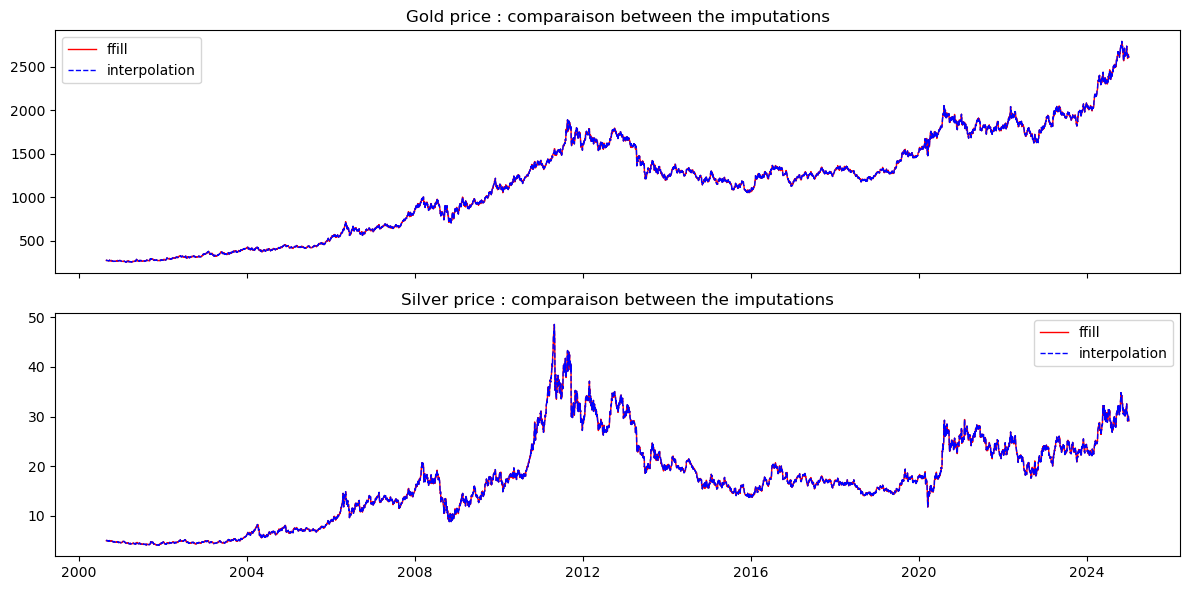

In [5]:
# Visual comparaison between ffill vs interpolation 
df_interp = impute_missing(df_raw, method="interpolate")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df["gold"], label="ffill", linewidth=1, color="red")
axes[0].plot(df_interp["gold"], label="interpolation", linewidth=1, color="blue", linestyle="--")
axes[0].set_title("Gold price : comparaison between the imputations")
axes[0].legend()

axes[1].plot(df["silver"], label="ffill", linewidth=1, color="red")
axes[1].plot(df_interp["silver"], label="interpolation", linewidth=1, color="blue", linestyle="--")
axes[1].set_title("Silver price : comparaison between the imputations")
axes[1].legend()

plt.tight_layout()
plt.show()

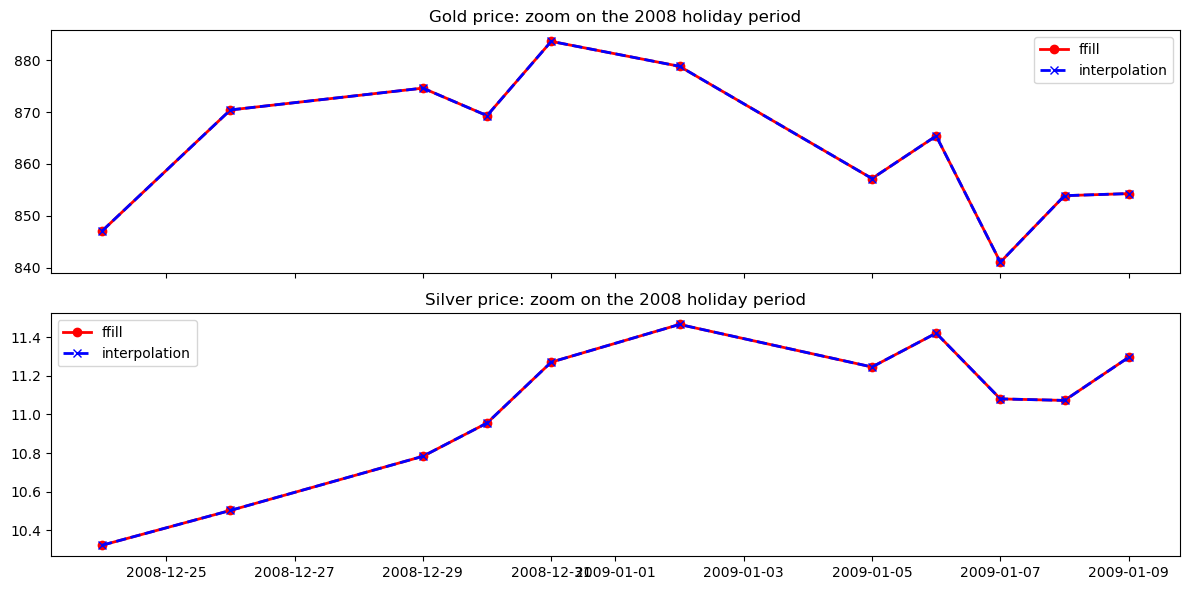

In [6]:
# Zoom on a window with a high density of public holidays
start = "2008-12-24"
end = "2009-01-10"

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df["gold"][start:end], label="ffill", linewidth=2, color="red", marker="o")
axes[0].plot(df_interp["gold"][start:end], label="interpolation", linewidth=2, color="blue", marker="x", linestyle="--")
axes[0].set_title("Gold price: zoom on the 2008 holiday period")
axes[0].legend()

axes[1].plot(df["silver"][start:end], label="ffill", linewidth=2, color="red", marker="o")
axes[1].plot(df_interp["silver"][start:end], label="interpolation", linewidth=2, color="blue", marker="x", linestyle="--")
axes[1].set_title("Silver price: zoom on the 2008 holiday period")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.4 Transformation: log-price, log-ration and returns

Raw prices are transformed into log-prices in order to stabilize the variance of the series and liearize the relationship between variables.
The gold/silver log-ratio measures the relative value of gold against silver and is used to examine whether a stable long-run relationship exists between the two metals. An increase indicates that gold is outperforming silver, a decrease the opposite.

In [5]:
df = add_log_returns(df, price_cols=["gold", "silver"])
df = add_log_ratio(df, col_a="log_gold", col_b="log_silver")

df.head()

,gold,silver,log_gold,dlog_gold,log_silver,dlog_silver,log_ratio
Date,,,,,,,
2000-08-30,273.899994,4.930,5.612763,NaN,1.595339,NaN,4.017424
2000-08-31,278.299988,5.003,5.628700,0.015937,1.610038,0.014699,4.018662
2000-09-01,277.000000,5.004,5.624018,-0.004682,1.610238,0.000200,4.013780
2000-09-05,275.799988,4.998,5.619676,-0.004342,1.609038,-0.001200,4.010638
2000-09-06,274.200012,4.983,5.613858,-0.005818,1.606032,-0.003006,4.007826


In [9]:
save_processed(df, "gold_silver_processed.csv")

Données transformées sauvegardées : ../data/processed/gold_silver_processed.csv


## 3. Analyse descriptive

### 3.1 Graphiques des log-prix et du log-ratio



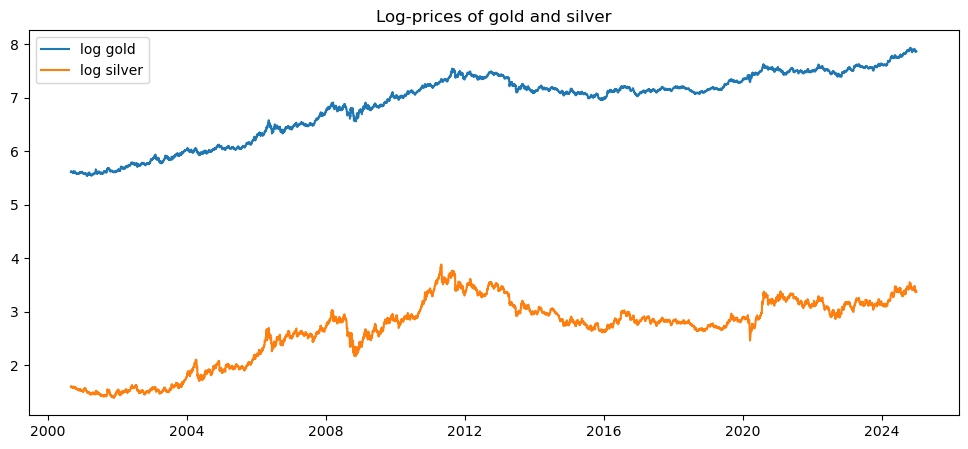

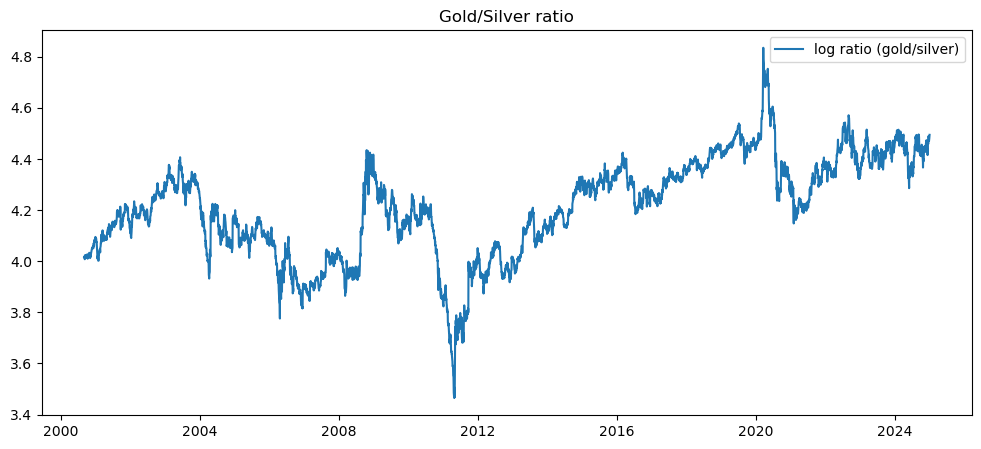

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["log_gold"], label="log gold")
plt.plot(df.index, df["log_silver"], label="log silver")
plt.title("Log-prices of gold and silver")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["log_ratio"], label="log ratio (gold/silver)")
plt.title("Gold/Silver ratio")
plt.legend()
plt.show()

Both series exhibit a persistent upward drift with no reversion to a fixed mean, consistent with the non-stationary, I(1) behavior expected of financial log-prices, but their broadly parallel movement, particularly from 2008 onward, suggests a common long-run relationship worth formally testing for cointegration.

The gold/silver log-ratio shows no systematic reversion to a stable mean over 2000–2024, with a clear upward trend since 2011. The 2011 trough reflects silver's speculative surge, while the 2020 peak reflects gold's stronger safe-haven appeal during the Covid shock, as silver remained more exposed to industrial demand. This visual instability foreshadows the rejection of stationarity for the log-ratio, formally tested in the next notebook, and points to the sub-period and rolling-window approach used later in the analysis.

### 3.2 Statistiques descriptives

In [11]:
stat_desc = df[["gold", "silver", "log_gold", "log_silver", "log_ratio"]].describe()
display(stat_desc)

,gold,silver,log_gold,log_silver,log_ratio
count,6108.000000,6108.000000,6108.000000,6108.000000,6108.000000
mean,1160.466552,17.044065,6.888745,2.680254,4.208490
std,580.349448,8.498464,0.633132,0.603416,0.192802
min,255.100006,4.026000,5.541656,1.392773,3.465582
25%,630.375000,11.478750,6.446315,2.440497,4.078893
50%,1233.700012,16.747000,7.117773,2.818219,4.218857
75%,1615.199951,22.680501,7.387214,3.121506,4.352910
max,2788.500000,48.584000,7.933259,3.883294,4.835396


The gold/silver scale mismatch (255–2789 vs 4–49) motivates the log transformation used throughout. In log terms, gold and silver show comparable dispersion (std ≈ 0.63 and 0.60), while the log-ratio's low unconditional standard deviation (0.19) is misleading, it reflects a static, order-blind summary that masks the persistent time trend already identified visually, reinforcing the need for the stationarity tests that follow.

In [12]:
higher_moments = pd.DataFrame({
    "skewness": df[["gold", "silver", "log_gold", "log_silver", "log_ratio"]].skew(),
    "kurtosis": df[["gold", "silver", "log_gold", "log_silver", "log_ratio"]].kurtosis(),
})

display(higher_moments)

,skewness,kurtosis
gold,0.100156,-0.718724
silver,0.375349,-0.226261
log_gold,-0.733237,-0.703122
log_silver,-0.713359,-0.464713
log_ratio,-0.342492,-0.013322


Skewness and kurtosis stay close to zero across all series, showing no major departure from normality at the distributional level.

## 4. Sample splitting

The sample is split into three sub-periods using a 70/15/15 rule:

- **Training (70%)**: model estimation and hyperparameter selection.
- **Validation (15%)**: selection of the VAR lag order via recursive out-of-sample forecasting.
- **Test (15%)**: final evaluation of predictive performance.

The split is not saved to disk: it is recomputed on the fly in each notebook via `train_val_test_split(df)`, based on `gold_silver_processed.csv`.

In [7]:
df_train, df_val, df_test = train_val_test_split(df, train_frac=0.70, val_frac=0.85)

split_table = pd.DataFrame({
    "Sub-sample": ["Training", "Validation", "Test"],
    "Start": [df_train.index.min().date(), df_val.index.min().date(), df_test.index.min().date()],
    "End": [df_train.index.max().date(), df_val.index.max().date(), df_test.index.max().date()],
    "Number of observations": [len(df_train), len(df_val), len(df_test)],
})

display(split_table)

,Sub-sample,Start,End,Number of observations
0,Training,2000-08-30,2017-09-14,4275
1,Validation,2017-09-15,2021-05-07,916
2,Test,2021-05-10,2024-12-30,917


# PART II. Multivariate macro-financial model

## 1. Introduction and motivation

The bivariate gold–silver framework studied in Part I ignores the macro-financial
factors common to both metals. The instability of the bivariate cointegration
observed (see `02_Stationarity_and_Cointegration.ipynb`) can be partly explained
by the omission of relative price and opportunity cost variables.

Two macro variables are added to the system:
- **DXY** (`dxy`) : US dollar index. Precious metals are priced in dollars, so a dollar appreciation mechanically weighs on their price, this inverse relationship is precisely what motivates including the dollar in the system.

- **US 10Y** (`us10y`) : 10-year US sovereign yield. A proxy for the opportunity cost of holding a non-yielding asset such as gold or silver. A rising yield makes bonds more attractive, prompting investors to shift capital away from non-yielding assets like gold and silver toward interest-bearing ones, which puts downward pressure on their prices.

The multivariate system `{log_gold, log_silver, log_dxy, us10y}` will be used in
the next the following notebook

## 2. Data and preparation

### 2.1 Downloading macro-financial data

The tickers are defined in `data_loader.ASSETS_MULTIVARIE`: `GC=F` (gold),
`SI=F` (silver), `DX-Y.NYB` (dollar index), `^TNX` (US 10-year yield).

In [11]:
from data_loader import ASSETS_BIVARIE, ASSETS_MULTIVARIE, load_market_data, save_raw

df_macro_raw = load_market_data(ASSETS_MULTIVARIE, start="2000-01-01", end="2024-12-31")

print("Initial number of observations :", len(df_macro_raw))
print("\nMissing values before imputation :")
print(df_macro_raw.isna().sum())
print("\n NaN rate :")
print((df_macro_raw.isna().sum() / len(df_macro_raw) * 100).round(3), "%")

df_macro_raw.head()

Initial number of observations : 6319

Missing values before imputation :
gold      214
silver    212
dxy         4
us10y      37
dtype: int64

 NaN rate :
gold      3.387
silver    3.355
dxy       0.063
us10y     0.586
dtype: float64 %


,gold,silver,dxy,us10y
Date,,,,
2000-01-03,NaN,NaN,100.220001,6.548
2000-01-04,NaN,NaN,100.410004,6.485
2000-01-05,NaN,NaN,100.379997,6.599
2000-01-06,NaN,NaN,100.650002,6.549
2000-01-07,NaN,NaN,100.800003,6.504


In [5]:
print("First available date per asset:")
for col in df_macro_raw.columns:
    print(f"  {col:10s} : {df_macro_raw[col].first_valid_index().date()}")

First available date per asset:
  gold       : 2000-08-30
  silver     : 2000-08-30
  dxy        : 2000-01-03
  us10y      : 2000-01-03


Gold and silver (GC=F, SI=F) have no usable history on Yahoo Finance before late August 2000, unlike the dollar index and 10-year yield, which extend back to January 2000. The effective sample therefore starts on August 30, 2000 rather than January 1, 2000, a loss of about 8 months out of the ~25-year period, negligible given the sample size (over 6,000 daily observations).

### 2.2 Missing value imputation

Same approach as the bivariate model (Part I, section 2.3): forward fill, which avoids look-ahead bias. The four series do not necessarily share the exact same trading calendar (commodity markets vs. equity/rate markets holidays), resulting in a slightly higher NaN rate than in the bivariate setting.

In [9]:
df_macro = impute_missing(df_macro_raw, method="ffill")

print("Valeurs manquantes après ffill :")
print(df_macro.isna().sum())

df_macro.head()

Valeurs manquantes après ffill :
gold      0
silver    0
dxy       0
us10y     0
dtype: int64


,gold,silver,dxy,us10y
Date,,,,
2000-08-30,273.899994,4.930,112.139999,5.800
2000-08-31,278.299988,5.003,112.599998,5.729
2000-09-01,277.000000,5.004,111.419998,5.675
2000-09-05,275.799988,4.998,112.410004,5.683
2000-09-06,274.200012,4.983,114.120003,5.712


In [10]:
print(f"\nEffective sample start date (after imputation): {df_macro.index.min().date()}")


Effective sample start date (after imputation): 2000-08-30


### 2.3 Transformations: Log-prices and differences

`gold`, `silver` and `dxy` are prices: they are transformed into logs and then
first-differenced (logarithmic returns), via `add_log_returns`.

`us10y` is a **rate**, already expressed in levels rather than as a price:
unlike the other three series, no logarithmic transformation is applied to it.
Its first difference (`dus10y`) is computed directly, corresponding to the
change in the rate in percentage points, see the note in
`preprocessing.add_log_returns`.

In [12]:
from preprocessing import add_log_returns

df_macro = add_log_returns(df_macro, price_cols=["gold", "silver", "dxy"])

# us10y: handled separately, see note in preprocessing.add_log_returns
df_macro["dus10y"] = df_macro["us10y"].diff()

df_macro.head()

,gold,silver,dxy,us10y,log_gold,dlog_gold,log_silver,dlog_silver,log_dxy,dlog_dxy,dus10y
Date,,,,,,,,,,,
2000-08-30,273.899994,4.930,112.139999,5.800,5.612763,NaN,1.595339,NaN,4.719748,NaN,NaN
2000-08-31,278.299988,5.003,112.599998,5.729,5.628700,0.015937,1.610038,0.014699,4.723842,0.004094,-0.071
2000-09-01,277.000000,5.004,111.419998,5.675,5.624018,-0.004682,1.610238,0.000200,4.713307,-0.010535,-0.054
2000-09-05,275.799988,4.998,112.410004,5.683,5.619676,-0.004342,1.609038,-0.001200,4.722153,0.008846,0.008
2000-09-06,274.200012,4.983,114.120003,5.712,5.613858,-0.005818,1.606032,-0.003006,4.737251,0.015098,0.029


In [13]:
save_processed(df_macro, "gold_silver_macro_processed.csv")

Données transformées sauvegardées : ../data/processed/gold_silver_macro_processed.csv


## 3. Multivariate exploratory analysis

### 3.1 Series visualization

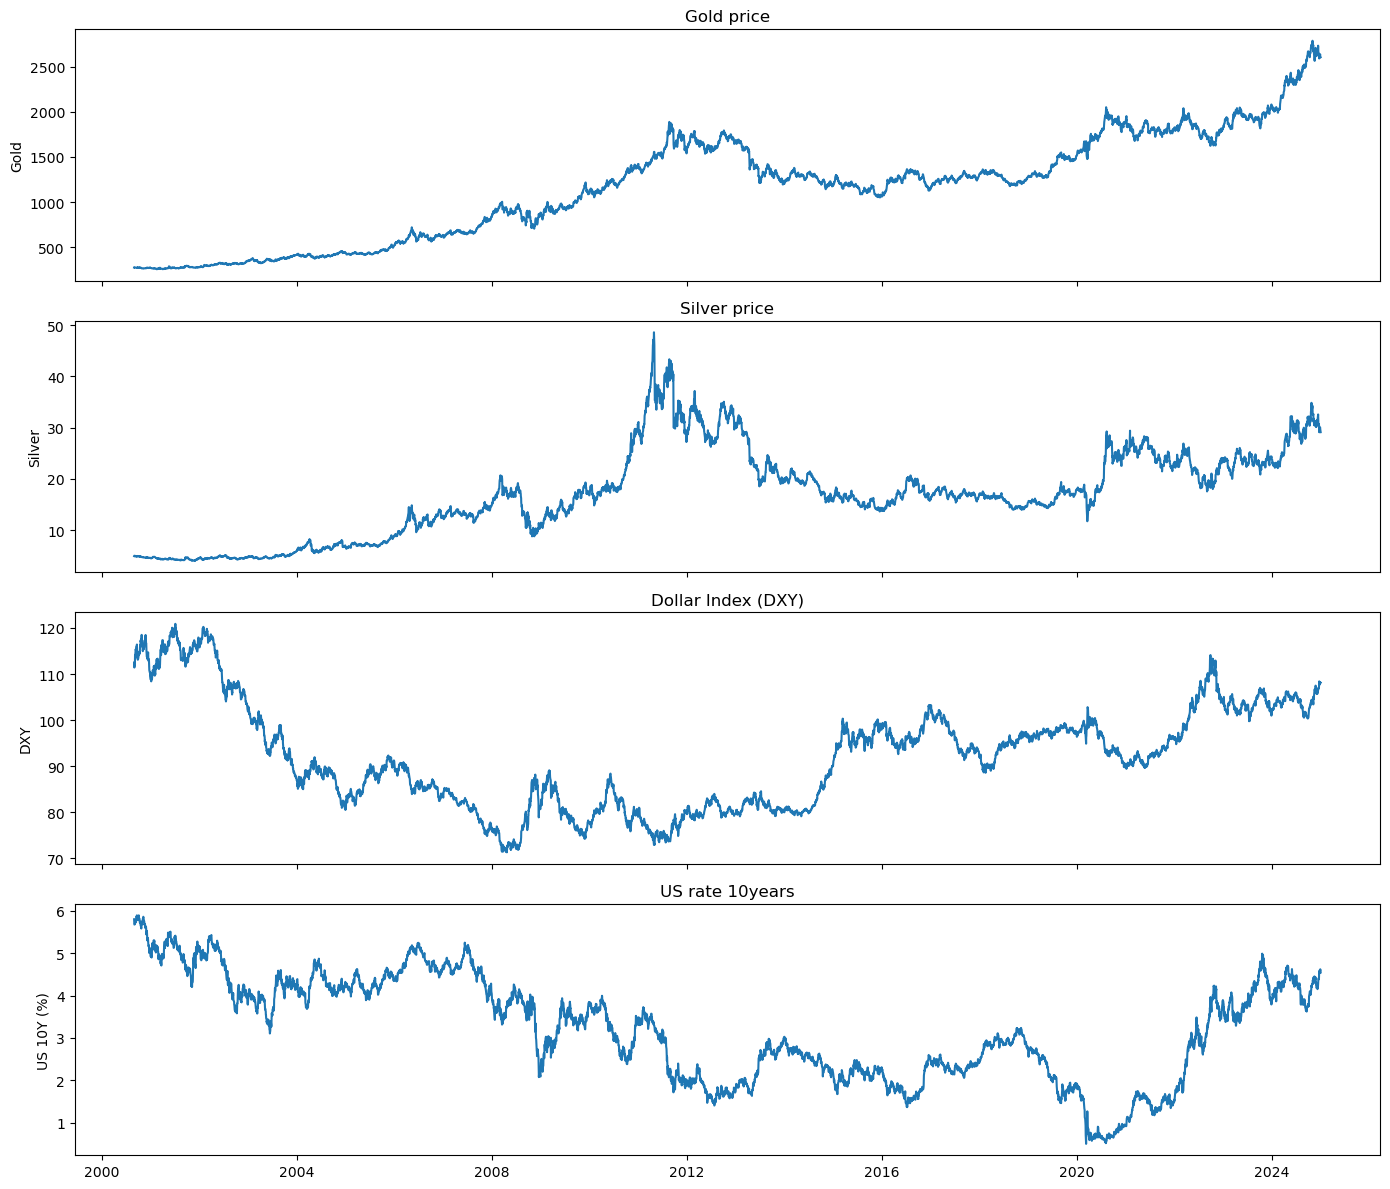

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df_macro.index, df_macro["gold"])
axes[0].set_title("Gold price")
axes[0].set_ylabel("Gold")

axes[1].plot(df_macro.index, df_macro["silver"])
axes[1].set_title("Silver price")
axes[1].set_ylabel("Silver")

axes[2].plot(df_macro.index, df_macro["dxy"])
axes[2].set_title("Dollar Index (DXY)")
axes[2].set_ylabel("DXY")

axes[3].plot(df_macro.index, df_macro["us10y"])
axes[3].set_title("US rate 10years")
axes[3].set_ylabel("US 10Y (%)")

plt.tight_layout()
plt.show()

As in the bivariate analysis, gold and silver keep trending upward together. The dollar index moves the opposite way, especially its 2003–2008 drop and its rise after 2021, in line with the inverse link between the dollar and dollar-priced commodities. The 10-year yield trends down from 2000 to its 2020 Covid low, then rises sharply from 2022 as the Fed tightened policy, yet gold and silver kept rising too, suggesting other drivers (inflation, geopolitical risk) dominated over that stretch. This doesn't disprove the mechanism, a multivariate model can still confirm the yield's negative effect on gold once the dollar is controlled for, which would mean the 2022+ co-movement comes from factors outside this system (though this model can't confirm which).

### 3.2 Statistiques descriptives

In [15]:
cols_macro = [
    "gold", "silver", "dxy", "us10y",
    "log_gold", "log_silver", "log_dxy",
    "dlog_gold", "dlog_silver", "dlog_dxy", "dus10y",
]

stat_desc_macro = df_macro[cols_macro].describe().T
stat_desc_macro

,count,mean,std,min,25%,50%,75%,max
gold,6149.0,1155.606521,581.774841,255.100006,625.400024,1231.199951,1612.300049,2788.500000
silver,6149.0,16.974417,8.516594,4.026000,11.217000,16.711000,22.646999,48.584000
dxy,6149.0,92.170522,11.271634,71.330002,82.309998,92.260002,99.169998,120.900002
us10y,6149.0,3.198924,1.225993,0.499000,2.181000,3.193000,4.225000,5.892000
log_gold,6149.0,6.882652,0.636157,5.541656,6.438391,7.115745,7.385417,7.933259
log_silver,6149.0,2.674434,0.606321,1.392773,2.417430,2.816067,3.120027,3.883294
log_dxy,6149.0,4.516270,0.121098,4.267317,4.410493,4.524611,4.596836,4.794964
dlog_gold,6148.0,0.000366,0.010836,-0.098206,-0.004698,0.000425,0.006123,0.086432
dlog_silver,6148.0,0.000289,0.019700,-0.195457,-0.008368,0.000784,0.010053,0.121958
dlog_dxy,6148.0,-0.000006,0.004865,-0.027169,-0.002773,0.000000,0.002746,0.025237


Return series (dlog_*, dus10y) are on comparable scales, unlike the raw levels. Silver's return volatility (std ≈ 0.020) is nearly double gold's (std ≈ 0.011), consistent with its added industrial-demand exposure.Silver's extreme return range (-19.5% to +12.2%) stands out and will be examined more closely in the distribution analysis below.



In [16]:
higher_moments_macro = pd.DataFrame({
    "skewness": df_macro[cols_macro].skew(),
    "kurtosis": df_macro[cols_macro].kurtosis(),
})

higher_moments_macro

,skewness,kurtosis
gold,0.107747,-0.730344
silver,0.380068,-0.235506
dxy,0.381700,-0.561597
us10y,-0.050480,-0.998188
log_gold,-0.716967,-0.740211
log_silver,-0.698036,-0.505670
log_dxy,0.156505,-0.764585
dlog_gold,-0.296166,5.417251
dlog_silver,-0.795296,6.988673
dlog_dxy,-0.030942,1.699810


Skewness stays close to zero for levels and log-levels, but kurtosis jumps for the return series, especially dlog_silver (6.99) and dlog_gold (5.42), confirming the fat tails already hinted at by silver's extreme return range. This is standard for daily financial returns, driven by occasional sharp market shocks, and it's the reason robust standard errors are used later in the diagnostics rather than assuming normality.

## 4. Sample Splitting

Same 70/15/15 rule as in the bivariate model (see Part I, section 4), applied to
the full multivariate DataFrame. The split is not saved to disk and will be
recomputed on the fly in the following notebooks via `train_val_test_split(df_macro)`.

In [17]:
df_macro_train, df_macro_val, df_macro_test = train_val_test_split(
    df_macro, train_frac=0.70, val_frac=0.85
)

split_table_macro = pd.DataFrame({
    "Sub-sample": ["Training", "Validation", "Test"],
    "Start": [df_macro_train.index.min().date(), df_macro_val.index.min().date(), df_macro_test.index.min().date()],
    "End": [df_macro_train.index.max().date(), df_macro_val.index.max().date(), df_macro_test.index.max().date()],
    "Number of observations": [len(df_macro_train), len(df_macro_val), len(df_macro_test)],
})

split_table_macro

,Sub-sample,Start,End,Number of observations
0,Training,2000-08-30,2017-08-29,4304
1,Validation,2017-08-30,2021-04-29,922
2,Test,2021-04-30,2024-12-30,923
